# Notebook 05 — Model Comparison
Final side-by-side comparison of all candidates. Latency benchmarks. Save full report for `docs/model_selection.md`.

In [13]:
# ── Mount Drive ──────────────────────────────────────────────
from google.colab import drive
drive.mount('/content/drive')

import sys, os

# ── Point Python at your project files ───────────────────────
PROJECT = '/content/drive/MyDrive/waf-ml-project/ml'
sys.path.insert(0, PROJECT)           # so   import feature_engineering   works
os.chdir(PROJECT)                     # so   Path("../data/...")   resolves
print(f"Working dir: {os.getcwd()}")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Working dir: /content/drive/MyDrive/waf-ml-project/ml


In [14]:
 %%capture
 !pip install -r /content/drive/MyDrive/waf-ml-project/ml/requirements_train.txt # run once

In [15]:
%%capture
!pip install scikit-learn xgboost torch onnx onnxruntime \
             skl2onnx mlflow tqdm seaborn scipy pandas openpyxl

In [16]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))
import numpy as np
import pandas as pd
import json
import matplotlib.pyplot as plt
from pathlib import Path

from evaluation.compare_models import compare_l2a, compare_l2b, save_full_report
# FIX: import individual benchmark functions — benchmark_all() misidentifies L2A model
from evaluation.benchmark import (benchmark_autoencoder, benchmark_gru,
                                   benchmark_isolation_forest, benchmark_cnn_1d,
                                   benchmark_xgboost, print_report)

EXPORTS = Path("../exported_models")


In [17]:
# ── Sync results JSON from NB03 and NB04 ─────────────────────────────────────
# NB03 and NB04 now save l2a_results.json and l2b_results.json automatically.
# This cell verifies they exist and prints a preview.

for fname in ["l2a_results.json", "l2b_results.json"]:
    p = EXPORTS / fname
    if p.exists():
        with open(p) as f:
            data = json.load(f)
        print(f"✅ {fname} — winner: {data['winner']},  {len(data['results'])} candidates")
    else:
        print(f"❌ {fname} not found — run NB03/NB04 first")


✅ l2a_results.json — winner: shallow_autoencoder,  2 candidates
✅ l2b_results.json — winner: gru,  3 candidates


## 1. Load saved results

In [18]:
with open(EXPORTS / "l2a_results.json") as f:
    l2a_data = json.load(f)
with open(EXPORTS / "l2b_results.json") as f:
    l2b_data = json.load(f)

l2a_results = l2a_data["results"]
l2b_results = l2b_data["results"]
l2a_winner  = l2a_data["winner"]
l2b_winner  = l2b_data["winner"]

print(f"L2A winner: {l2a_winner}")
print(f"L2B winner: {l2b_winner}")

L2A winner: shallow_autoencoder
L2B winner: gru


## 2. Layer 2A comparison table

In [19]:
df_l2a = compare_l2a(l2a_results)
df_l2a


=== Layer 2A Model Comparison ===
              Model    AUC  Avg Precision  TPR (recall)    FPR   TP  FP  TN   FN
shallow_autoencoder 0.9832         0.9974        0.9233 0.0227 4308  17 733  358
   isolation_forest 0.9293         0.9842        0.3701 0.0320 1727  24 726 2939


,Model,AUC,Avg Precision,TPR (recall),FPR,TP,FP,TN,FN
1,shallow_autoencoder,0.9832,0.9974,0.9233,0.0227,4308,17,733,358
0,isolation_forest,0.9293,0.9842,0.3701,0.0320,1727,24,726,2939


## 3. Layer 2B comparison table

In [20]:
df_l2b = compare_l2b(l2b_results)
df_l2b


=== Layer 2B Model Comparison ===
  Model  Macro F1  Accuracy  F1 (normal)  F1 (sqli)  F1 (xss)  F1 (lfi)  F1 (other_attack)
    gru    0.9936    0.9944       0.9960     0.9967    0.9873    0.9978             0.9900
 cnn_1d    0.9886    0.9893       0.9907     0.9983    0.9796    0.9956             0.9789
xgboost    0.9561    0.9549       0.9534     0.9917    0.9466    0.9879             0.9009


,Model,Macro F1,Accuracy,F1 (normal),F1 (sqli),F1 (xss),F1 (lfi),F1 (other_attack)
2,gru,0.9936,0.9944,0.9960,0.9967,0.9873,0.9978,0.9900
1,cnn_1d,0.9886,0.9893,0.9907,0.9983,0.9796,0.9956,0.9789
0,xgboost,0.9561,0.9549,0.9534,0.9917,0.9466,0.9879,0.9009


## 4. ONNX latency benchmark — all exported models

In [21]:
# FIX: benchmark_all() auto-detects model type from filename and incorrectly
# classifies layer2a_best.onnx as L2B (looks for 'l2a' in stem, misses it).
# Use individual benchmark functions with explicit input format instead.

lat_results = []

# Layer 2A — autoencoder uses numeric features (1, INPUT_DIM) float32
l2a_onnx = str(EXPORTS / "layer2a_best.onnx")
try:
    lat_l2a = benchmark_autoencoder(l2a_onnx)
    lat_l2a["layer"]     = "L2A"
    lat_l2a["target_ms"] = 2.0
    lat_l2a["pass"]      = lat_l2a["p99_ms"] <= 2.0
    lat_results.append(lat_l2a)
    print(f"L2A benchmark: mean={lat_l2a['mean_ms']}ms  p99={lat_l2a['p99_ms']}ms  "
          f"{'PASS' if lat_l2a['pass'] else 'FAIL'}")
except Exception as e:
    print(f"L2A benchmark error: {e}")

# Layer 2B — GRU winner uses token sequences (1, 512) int64
l2b_onnx = str(EXPORTS / "layer2b_best.onnx")
try:
    # Load winner name to pick the right benchmark function
    with open(EXPORTS / "l2b_results.json") as f:
        l2b_winner = json.load(f)["winner"]

    if l2b_winner == "gru":
        lat_l2b = benchmark_gru(l2b_onnx)
    elif l2b_winner == "cnn_1d":
        lat_l2b = benchmark_cnn_1d(l2b_onnx)
    else:
        lat_l2b = benchmark_xgboost(l2b_onnx)

    lat_l2b["layer"]     = "L2B"
    lat_l2b["target_ms"] = 20.0
    lat_l2b["pass"]      = lat_l2b["p99_ms"] <= 20.0
    lat_results.append(lat_l2b)
    print(f"L2B benchmark ({l2b_winner}): mean={lat_l2b['mean_ms']}ms  "
          f"p99={lat_l2b['p99_ms']}ms  {'PASS' if lat_l2b['pass'] else 'FAIL'}")
except Exception as e:
    print(f"L2B benchmark error: {e}")

print_report(lat_results)


L2A benchmark: mean=0.038ms  p99=0.158ms  PASS
L2B benchmark (gru): mean=28.744ms  p99=64.036ms  FAIL

ONNX Inference Latency Report
Model                          Layer     Mean      P95      P99   Target   Pass
-------------------------------------------------------------------------------
layer2a_best                   L2A      0.04ms    0.05ms    0.16ms     2.0ms   YES
layer2b_best                   L2B     28.74ms   50.48ms   64.04ms    20.0ms   NO 
Passed: 1/2


## 5. Summary chart

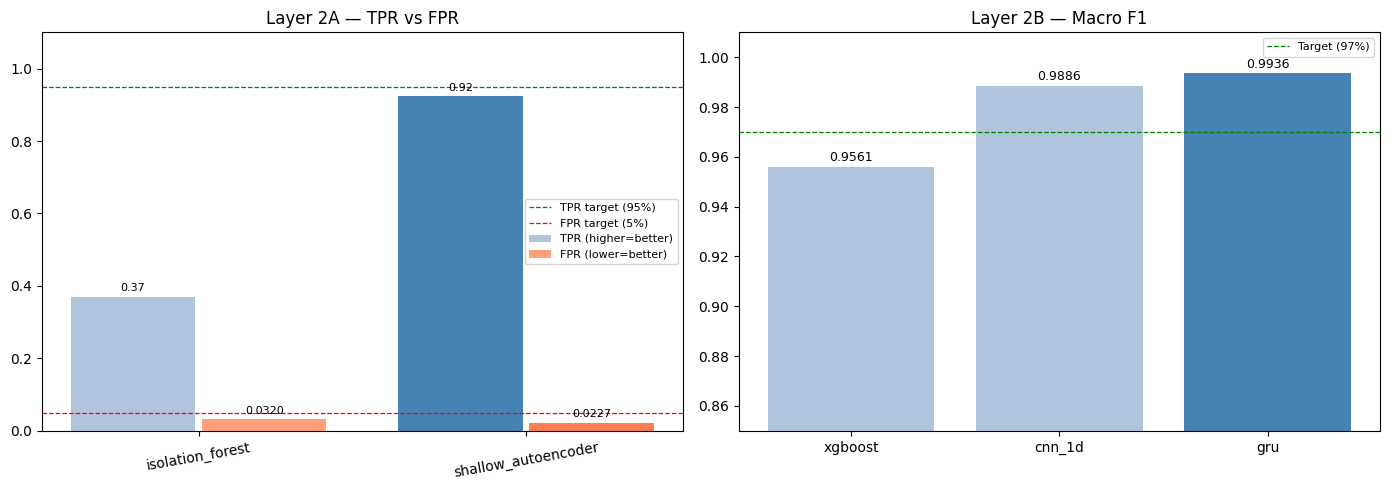

In [22]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# ── L2A: TPR and FPR side by side ────────────────────────────────────────────
models_l2a = [r["model"] for r in l2a_results]
fprs = [r["fpr"] for r in l2a_results]
tprs = [r["tpr"] for r in l2a_results]
x = range(len(models_l2a))
ax = axes[0]
bars_tpr = ax.bar([xi - 0.2 for xi in x], tprs, width=0.38,
                   color=["steelblue" if m == l2a_winner else "lightsteelblue"
                          for m in models_l2a], label="TPR (higher=better)")
bars_fpr = ax.bar([xi + 0.2 for xi in x], fprs, width=0.38,
                   color=["coral" if m == l2a_winner else "lightsalmon"
                          for m in models_l2a], label="FPR (lower=better)")
for bar in bars_tpr:
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.01,
            f"{bar.get_height():.2f}", ha="center", va="bottom", fontsize=8)
for bar in bars_fpr:
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.01,
            f"{bar.get_height():.4f}", ha="center", va="bottom", fontsize=8)
ax.axhline(0.95, color="green",  linestyle="--", linewidth=0.9, label="TPR target (95%)")
ax.axhline(0.05, color="red",    linestyle="--", linewidth=0.9, label="FPR target (5%)")
ax.set_xticks(list(x)); ax.set_xticklabels(models_l2a, rotation=10)
ax.set_title("Layer 2A — TPR vs FPR"); ax.set_ylim(0, 1.1)
ax.legend(fontsize=8)

# ── L2B: Macro F1 ─────────────────────────────────────────────────────────────
models_l2b = [r["model"] for r in l2b_results]
f1s        = [r["macro_f1"] for r in l2b_results]
ax2 = axes[1]
bars2 = ax2.bar(models_l2b, f1s,
                color=["steelblue" if m == l2b_winner else "lightsteelblue"
                       for m in models_l2b])
ax2.set_ylim(0.85, 1.01)
ax2.axhline(0.97, color="green", linestyle="--", linewidth=0.9, label="Target (97%)")
for bar, f1 in zip(bars2, f1s):
    ax2.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.001,
             f"{f1:.4f}", ha="center", va="bottom", fontsize=9)
ax2.set_title("Layer 2B — Macro F1"); ax2.legend(fontsize=8)

plt.tight_layout()
plt.savefig("../data/processed/05_model_comparison.png", dpi=120)
plt.show()


## 6. Save full report

In [23]:
save_full_report(l2a_results, l2b_results, lat_results,
                 str(EXPORTS / "full_model_report.json"))
print("Report saved. Copy results to docs/model_selection.md")

[compare] Full report saved → ../exported_models/full_model_report.json
Report saved. Copy results to docs/model_selection.md


## 7. vs Base Paper benchmarks

In [24]:
print("=== Comparison vs Base Papers ===")
print()
print("Base Paper 1 (ADL-WAF, Sameh & Selim):")
print("  Detection accuracy: 99.88%")
print("  Precision:          100%")
print()
print("Base Paper 2 (LSTM+GRU ensemble, Babaey & Faragardi 2025):")
print("  Accuracy:    97.58%")
print("  Precision:   99.99%")
print("  Recall:      97.52%")
print("  Specificity: 99.76%")
print("  FPR:         0.2%")
print()
print("Our Layer 2A results:")
for r in l2a_results:
    print(f"  {r['model']}: TPR={r['tpr']:.4f}  FPR={r['fpr']:.4f}  AUC={r['auc']:.4f}")
print()
print("Our Layer 2B results:")
for r in l2b_results:
    print(f"  {r['model']}: macro_F1={r['macro_f1']:.4f}  acc={r['accuracy']:.4f}")

=== Comparison vs Base Papers ===

Base Paper 1 (ADL-WAF, Sameh & Selim):
  Detection accuracy: 99.88%
  Precision:          100%

Base Paper 2 (LSTM+GRU ensemble, Babaey & Faragardi 2025):
  Accuracy:    97.58%
  Precision:   99.99%
  Recall:      97.52%
  Specificity: 99.76%
  FPR:         0.2%

Our Layer 2A results:
  isolation_forest: TPR=0.3701  FPR=0.0320  AUC=0.9293
  shallow_autoencoder: TPR=0.9233  FPR=0.0227  AUC=0.9832

Our Layer 2B results:
  xgboost: macro_F1=0.9561  acc=0.9549
  cnn_1d: macro_F1=0.9886  acc=0.9893
  gru: macro_F1=0.9936  acc=0.9944
